<a href="https://colab.research.google.com/github/marilb-ds/natural-language-processing/blob/main/Marina_Lima_Braga_Lab_1_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 1: Introduction to ScikitLearn and Classification Tasks

During this Lab, we aim to achieve the following:


*   Familiarize with <a href="https://scikit-learn.org/stable/"> scikit-learn </a>, an essential python library in data science;
*   learn how to approach a classification task with scikit-learn.

In this notebook, we learn to use Scikit-Learn with a practical example and then, in the second part, we will test our knowledge by doing some exercises.



# Part 1: A Classification Example With Scikit-Learn

We start our lab by implementing *Logistic Regression* using  scikit-learn.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

[[ -4.89287606  -2.66252415]
 [  1.53513244 -17.71701488]
 [  2.5182605   -1.84224519]
 [  2.44773955   1.22644053]
 [  0.26080952 -10.3608732 ]
 [ -4.93419853 -11.87491308]
 [-11.14091064  -9.02493302]
 [ -3.84650002  -3.26967085]
 [  1.72390928   0.94676316]
 [  0.22019842  -3.97495822]
 [ -9.5434103   -9.29414049]
 [ -8.84586911  -2.47017747]
 [ -3.15198613  -3.10866018]
 [  8.04758892  -3.1059307 ]
 [  4.51512226  -5.69626898]
 [  1.48372716  -4.72320859]
 [ -1.24619567  -0.08046855]
 [ -2.59060124  -7.7649853 ]
 [  1.97108005   0.72102173]
 [ -4.10939125 -13.24348766]
 [  1.15603709  -9.46665443]
 [  4.52015465   1.10731538]
 [  0.73655564  -8.96913345]
 [  5.58087117   0.20618247]
 [  3.07191791  -2.64967086]
 [  1.49878533   1.77028153]
 [  1.76912283  -3.97549865]
 [ -5.72999469  -3.06430279]
 [ -1.48573418  -2.71616512]
 [  0.75656778 -14.52489211]
 [  0.39325343   4.78726736]
 [  4.3525562    1.26046682]
 [  5.17701727  -2.62601201]
 [ -8.54351608 -12.89055219]
 [  5.22743541

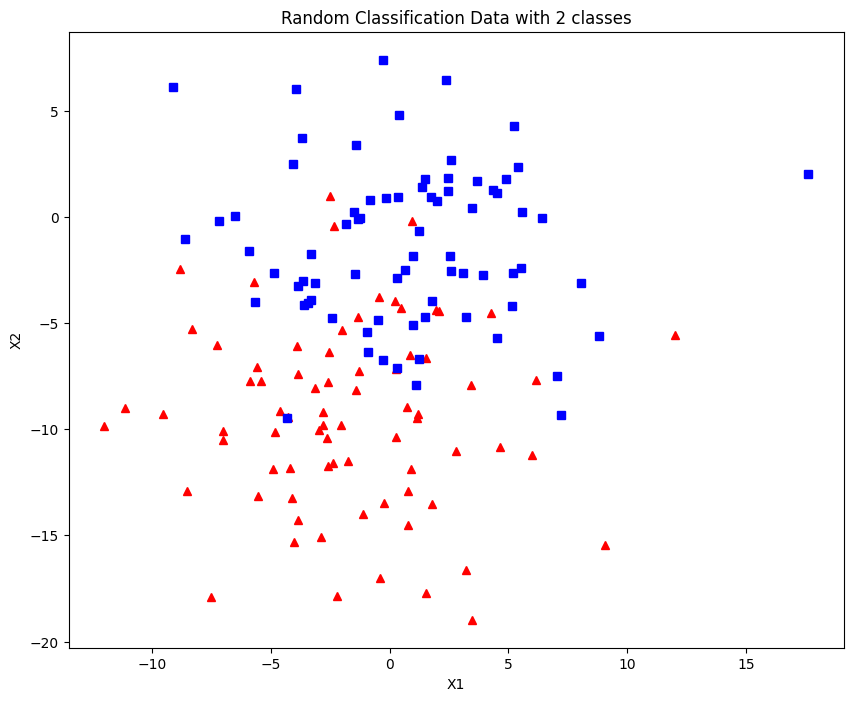

In [ ]:
from collections import Counter

X_toy, y_toy = datasets.make_blobs(n_samples=150,n_features=2,
                           centers=2,cluster_std=4.05,
                           random_state=2) # create an artificial dataset
print(X_toy)
print(y_toy)

print(Counter(y_toy))

#Plotting the data
fig = plt.figure(figsize=(10,8))
plt.plot(X_toy[:, 0][y_toy == 0], X_toy[:, 1][y_toy == 0], 'r^')
plt.plot(X_toy[:, 0][y_toy == 1], X_toy[:, 1][y_toy == 1], 'bs')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title('Random Classification Data with 2 classes')
plt.show()


We can now define our classifier: logistic regression <a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html"> [link] </a>.

In [ ]:
from sklearn.linear_model import LogisticRegression

clf_lr = LogisticRegression() # options for the classifiers are passed as parameters to constructor of the class
                              # LogisticRegression(). Either visit the link or put the cursor over it to see them


Sklearn defines standard functions for models, like *fit* and *predict*.

In [ ]:
#train phase
clf_lr.fit(X_toy, y_toy)


#estimation (y_hat)
y_pred_cl_lr = clf_lr.predict(X_toy)

print(y_pred_cl_lr)

[1 0 1 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 1
 0 1 0 0 1 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 0 0 0 1 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1
 1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 1 0 1 0 1 0 1 0 0 0 0 1 0
 1 1]


How to evaluate our models' performance? <br>
Scikit-learn offers a broad set of evaluation functions already implemented <a href = "https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics">[link]</a>.

In [ ]:
from sklearn.metrics import accuracy_score

print(f"Logistic Regression -- Toy dataset.\tACC: {accuracy_score(y_toy, y_pred_cl_lr)}")


Logistic Regression -- Toy dataset.	ACC: 0.8466666666666667


In [ ]:
# printing the values of the parameters after learning

print(clf_lr.coef_[0])


[0.13965618 0.50949503]


## Model Selection
When defining or training a model, we have the so called *hyperparameters*, i.e., different settings to configure for our training strategy.  <br>
The question is: *how can we decide the best configuration setting for the task?* <br>
The answer is the usage of *training* and *validation* partitions. <br>
We can use sklearn to do that: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_toy, y_toy,
                                                  train_size = 0.8, shuffle=False, random_state=42)

print(f"Original size = {X_toy.shape[0]}\tTrain size = {X_train.shape[0]}\tVal size = {X_val.shape[0]}")  # alternative way to use the print when there are
                                                                                                          # variables and text to print together


Original size = 150	Train size = 120	Val size = 30


First we use Scikit-Learn to train a <a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html">Logistic Regression</a> classifier with default parameters over the Toy dataset. <br>
We compute the accuracy on both training and validation sets.


In [ ]:
from sklearn.linear_model import LogisticRegression

clf_lr = LogisticRegression()
clf_lr.fit(X_train, y_train)

#estimation (y_hat)
y_train_pred_lr = clf_lr.predict(X_train)
y_val_pred_lr = clf_lr.predict(X_val)

print(f"Logistic Regression.\tTrain ACC: {accuracy_score(y_train, y_train_pred_lr)}")
print(f"Logistic Regression.\tVal ACC: {accuracy_score(y_val, y_val_pred_lr)}")

Logistic Regression.	Train ACC: 0.8416666666666667
Logistic Regression.	Val ACC: 0.8666666666666667


### Model Selection with Logistic Regression

Logistic Regression has a hyperparameter *C*. Lower values of C correspond to simpler models (with the risk of underfitting), higher values of C correspond to complex models (with the risk of overfitting).  
Let's see how the performance change by varying it.

Let's find the best *C* among the following: $C = [0.001, 0.01, 0.1, 1., 10]$.

In [ ]:
C = [0.001, 0.01, 0.1, 1., 10, 100]
for c in C:
    clf_lr = LogisticRegression(C = c)
    clf_lr.fit(X_train, y_train)

    #estimation (y_hat)
    y_train_pred_lr = clf_lr.predict(X_train)
    y_val_pred_lr = clf_lr.predict(X_val)
    tr_acc = accuracy_score(y_train, y_train_pred_lr)
    val_acc= accuracy_score(y_val, y_val_pred_lr)

    print(f"LR. C= {c}.\tTrain ACC: {tr_acc}\tVal Acc: {val_acc}")

LR. C= 0.001.	Train ACC: 0.8416666666666667	Val Acc: 0.9
LR. C= 0.01.	Train ACC: 0.8416666666666667	Val Acc: 0.9
LR. C= 0.1.	Train ACC: 0.8416666666666667	Val Acc: 0.8666666666666667
LR. C= 1.0.	Train ACC: 0.8416666666666667	Val Acc: 0.8666666666666667
LR. C= 10.	Train ACC: 0.8416666666666667	Val Acc: 0.8666666666666667
LR. C= 100.	Train ACC: 0.8416666666666667	Val Acc: 0.8666666666666667


### Exercise: Model Selection with Logistic Regression


We ask you again to work on a classification task. <br>
This time, the classification is more challenging.
The dataset is called *sonar*.

In [ ]:
import pandas as pd
import random
random.seed(42)

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv'
ds = pd.read_csv(url, header = None)

# split into input and output elements
data = ds.values
random.shuffle(data)
X_sonar, y_sonar = data[:, :-1], data[:, -1]

print(X_sonar.shape, y_sonar.shape)


(208, 60) (208,)


It's time to partition our dataset. <br>
We ask you to create three partitions:


*   *train set* : a set of samples used to train a model.
*   *val set*: a set of samples used to decide the best model.
*   *test set*: a set of samples used to see our best model performance.

We now first split samples that we can use in our training (train and val), from samples that we cannot touch (test). <br>
**EX 1** Create a split between train_val and test, by maintaining the 25% of samples in the test set.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X_sonar, y_sonar, test_size=0.25, random_state=42)

**EX 1.2** From the train_val variables, split train and validation sets. Maintain the 10% of samples in the validation.


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

In [ ]:
print(X_train.shape, X_val.shape, X_test.shape)

(140, 60) (16, 60) (52, 60)


**EX 2** Train and evaluate (using accuracy) a logistic regression with the default value for the hyperparameter. Do the evaluation **only** on the training and validation partitions.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create a Logistic Regression classifier with default hyperparameters
clf_lr = LogisticRegression()

# Train the classifier on the training data
clf_lr.fit(X_train, y_train)

# Make predictions on the training and validation sets
y_train_pred = clf_lr.predict(X_train)
y_val_pred = clf_lr.predict(X_val)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Print the accuracy scores
print(f"Logistic Regression - Train Accuracy: {train_accuracy}")
print(f"Logistic Regression - Validation Accuracy: {val_accuracy}")

Logistic Regression - Train Accuracy: 0.85
Logistic Regression - Validation Accuracy: 0.875


Let's find the best value for *C*, an hyperparameter of the model. <br>
See the documentation <a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html"> [link] </a>. <br>
**EX 3**  We ask you to find the best *C* among the following: $C = [0.001, 0.01, 0.1, 1., 10, 100, 1000, 10000]$.

In [ ]:
C = [0.001, 0.01, 0.1, 1., 10, 100, 1000, 10000]

best_C = None
best_val_accuracy = 0.0

for c in C:
    # Create a Logistic Regression classifier with the current C value
    clf_lr = LogisticRegression(C=c, random_state=42)  # Set random_state for reproducibility

    # Train the classifier on the training data
    clf_lr.fit(X_train, y_train)

    # Make predictions on the validation set
    y_val_pred = clf_lr.predict(X_val)

    # Calculate accuracy score on the validation set
    val_accuracy = accuracy_score(y_val, y_val_pred)

    # Print the accuracy score for the current C value
    print(f"LR. C= {c}.\tValidation Accuracy: {val_accuracy}")

    # Update best_C and best_val_accuracy if current C gives better performance
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_C = c

print(f"Best C: {best_C}, Best Validation Accuracy: {best_val_accuracy}")

LR. C= 0.001.	Validation Accuracy: 0.8125
LR. C= 0.01.	Validation Accuracy: 0.8125
LR. C= 0.1.	Validation Accuracy: 0.8125
LR. C= 1.0.	Validation Accuracy: 0.875
LR. C= 10.	Validation Accuracy: 0.8125
LR. C= 100.	Validation Accuracy: 0.75
LR. C= 1000.	Validation Accuracy: 0.8125
LR. C= 10000.	Validation Accuracy: 0.8125
Best C: 1.0, Best Validation Accuracy: 0.875


**Ex 4** It's time to see the performance on the test set of the best model, after training it on the training set. Use the accuracy as evaluation metric.

In [ ]:
# Create a Logistic Regression classifier with the best C value
best_clf_lr = LogisticRegression(C=best_C, random_state=42)

# Train the classifier on the training data
best_clf_lr.fit(X_train, y_train)

# Make predictions on the test set
y_test_pred = best_clf_lr.predict(X_test)

# Calculate accuracy score on the test set
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print the test accuracy
print(f"Logistic Regression - Test Accuracy with Best C ({best_C}): {test_accuracy}")

Logistic Regression - Test Accuracy with Best C (1.0): 0.8461538461538461


## Computing Vectorial Representations

In [ ]:
!python -m spacy download "en_core_web_sm"
import spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 42.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is this the first document or the forth?',
]
Y = [1, 0, 0, 1]


vectorizer = CountVectorizer()
vectorizer.fit(corpus)            # extracts the vocabulary from corpus (the list of unique words in corpus)
X = vectorizer.transform(corpus)  # build the bag of words representation of corpus with respect to the vocabulary computed with fit on the previous row

print(vectorizer.get_feature_names_out())
print("vocabulary size:", len(vectorizer.get_feature_names_out()))

# Let's see some of the options of CountVectorizer (first we change the tokenizer)
nlp_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

def spacy_tokenizer(text):
  return [token.text for token in nlp_en(text)]

vectorizer2 = CountVectorizer(binary=False, tokenizer=spacy_tokenizer)
X=vectorizer2.fit_transform(corpus)

print(vectorizer2.get_feature_names_out())
print("vocabulary size:", len(vectorizer2.get_feature_names_out()))

# now we can use X and Y in a learning algorithm


['and' 'document' 'first' 'forth' 'is' 'one' 'or' 'second' 'the' 'third'
 'this']
vocabulary size: 11
['.' '?' 'and' 'document' 'first' 'forth' 'is' 'one' 'or' 'second' 'the'
 'third' 'this']
vocabulary size: 13


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


#Sentiment Analysis

The dataset is described here: https://www.aclweb.org/anthology/P04-1035.pdf

It is part of nltk, so it is convenient for us to use.

The goal of this exercise is to build a first machine learning model using the tools that we have seen so far: choose how to preprocess the text, create a bag of words feature representation, train a model using an ML method of your choice.

You need to use the following split for the data:

*   test: 30% of the documents
*   The rest of the documents will be split as
    *   train: 75% of the documents
    *   validation: 25% of the documents

After splitting the data, turn the reviews into vectors, then apply a ML algorithm. Use accuracy as evaluation measure.

In [ ]:
import nltk
nltk.download('movie_reviews') # loads the dataset
nltk.download('punkt')
#!python -m spacy download "en_core_web_sm"


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## Loading the data
In the following I extract the raw content of the reviews (movie_reviews.raw()), i.e. each review is a string.
Another option is to use movie_reviews.words() that returns each review as a list of tokens. Feel free to use whichever best fit your needs.


In [ ]:
  from nltk.corpus import movie_reviews
  import random
  import spacy
  from scipy.sparse import coo_matrix, vstack
  import matplotlib.pyplot as plt
  from sklearn.linear_model import LogisticRegression
  from sklearn.feature_extraction.text import CountVectorizer

  nlp_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

  documents = [(movie_reviews.raw(fileid), category)
                for category in movie_reviews.categories()
                for fileid in movie_reviews.fileids(category)]

  print("number of docs loaded:", len(documents))

  corpus_raw = [ x[0] for x in documents ]  # corpus_raw is a list of strings (reviews) to be converted into vectors
  y_corpus = [ x[1] for x in documents ]    # y_corpus are the sentiment labels of the reviews (nothing to be done here)
  print(corpus_raw[0])
  print(y_corpus[0])

  random.seed(42)


number of docs loaded: 2000
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in which you , as an 

## Exercise - Lab. 1 Assignment

Create a vectorial representation of the data, then apply a learning algorithm by optimising the hyperparameters on the validation set. If you need to use any function that depends on random number generators, use 42 as seed.
Test several representations. You may try functions of the libraries we have seen in class or make your own vectorial representation from scratch.
Once you have selected the best hyperparameters and preprocessing, retrain your model on the union of the training and validation sets, then compute the accuracy on the test set.

Report your test performance on Moodle. In Moodle you are also supposed to upload the notebook in .py format (Menu File->Download->Download .py)
In the file with your code motivate any significant choice you made and all different preprocessing you attempted (clearly highlight the best one, though).

**Bonus Exercise** for your best model, print the 30 tokens whose corresponding parameter have highest absolute value. What do you think of this list? Does it make sense? Are all tokens expected?


### Import Libraries

In [ ]:
import numpy as np
import nltk
from nltk.corpus import movie_reviews
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import spacy

# Load English NLP model
nlp_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

###Load and Preprocess Data

In [ ]:
# Load movie reviews dataset
documents = [(movie_reviews.raw(fileid), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Extract text and labels
corpus_raw = [x[0] for x in documents]
y_corpus = np.array([1 if x[1] == "pos" else 0 for x in documents])

# Split dataset into Train (70%) and Test (30%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    corpus_raw, y_corpus, test_size=0.3, random_state=42
)

# Further split into Train (75%) and Validation (25%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(f"Train set: {len(X_train)}, Validation set: {len(X_val)}, Test set: {len(X_test)}")



Train set: 1050, Validation set: 350, Test set: 600


###Create Text Representations

####Bag-of-Words (BoW)

In [ ]:
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)
X_test_bow = bow_vectorizer.transform(X_test)



####TF-IDF

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)



####SpaCy Word Embeddings

In [ ]:
def spacy_vectorize(texts, nlp_model):
    return np.array([nlp_model(text).vector for text in texts])

X_train_spacy = spacy_vectorize(X_train, nlp_en)
X_val_spacy = spacy_vectorize(X_val, nlp_en)
X_test_spacy = spacy_vectorize(X_test, nlp_en)



###Hyperparameter Tuning with GridSearchCV

In [ ]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],  # Regularization strength
    "max_iter": [100, 200, 500],   # Number of iterations
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
def train_and_tune(X_train, X_val, y_train, y_val):
    log_reg = LogisticRegression(random_state=42, class_weight="balanced", solver="liblinear")

    grid_search = GridSearchCV(
        log_reg, param_grid, cv=cv_strategy, scoring="accuracy", n_jobs=-1, verbose=1
    )
    grid_search.fit(X_train, y_train)

    # Evaluate on validation set
    best_model = grid_search.best_estimator_
    y_val_pred = best_model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)

    print(f"Best Hyperparameters: {grid_search.best_params_}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

    return best_model, val_acc

# Train models for each representation
print("\nTraining BoW Model...")
best_bow_model, acc_bow = train_and_tune(X_train_bow, X_val_bow, y_train, y_val)

print("\nTraining TF-IDF Model...")
best_tfidf_model, acc_tfidf = train_and_tune(X_train_tfidf, X_val_tfidf, y_train, y_val)

print("\nTraining SpaCy Model...")
best_spacy_model, acc_spacy = train_and_tune(X_train_spacy, X_val_spacy, y_train, y_val)



Training BoW Model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Hyperparameters: {'C': 0.1, 'max_iter': 100}
Validation Accuracy: 0.8314

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       181
           1       0.83      0.82      0.82       169

    accuracy                           0.83       350
   macro avg       0.83      0.83      0.83       350
weighted avg       0.83      0.83      0.83       350


Training TF-IDF Model...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Hyperparameters: {'C': 10, 'max_iter': 100}
Validation Accuracy: 0.8314

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.83       181
           1       0.82      0.84      0.83       169

    accuracy                           0.83       350
   macro avg       0.83      0.83      0.83       350
weighted avg       0.83  

###Select Best Model & Retrain on Train + Validation

In [ ]:
# Select the best model based on validation accuracy
best_model = None
best_representation = None

if max(acc_bow, acc_tfidf, acc_spacy) == acc_bow:
    best_model = best_bow_model
    best_representation = "BoW"
    X_train_final = bow_vectorizer.fit_transform(X_train_val)
    X_test_final = bow_vectorizer.transform(X_test)
elif max(acc_bow, acc_tfidf, acc_spacy) == acc_tfidf:
    best_model = best_tfidf_model
    best_representation = "TF-IDF"
    X_train_final = tfidf_vectorizer.fit_transform(X_train_val)
    X_test_final = tfidf_vectorizer.transform(X_test)
else:
    best_model = best_spacy_model
    best_representation = "SpaCy"
    X_train_final = spacy_vectorize(X_train_val, nlp_en)
    X_test_final = spacy_vectorize(X_test, nlp_en)

print(f"\nBest Model: {best_representation}")

# Retrain best model on Train + Validation set
best_model.fit(X_train_final, y_train_val)



Best Model: BoW


LogisticRegression(C=0.1, class_weight='balanced', random_state=42,
                   solver='liblinear')

###Evaluate on test set

In [ ]:
y_test_pred = best_model.predict(X_test_final)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("\nFinal Classification Report:\n", classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))



Test Accuracy: 0.8183

Final Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.81      0.82       302
           1       0.81      0.82      0.82       298

    accuracy                           0.82       600
   macro avg       0.82      0.82      0.82       600
weighted avg       0.82      0.82      0.82       600


Confusion Matrix:
 [[246  56]
 [ 53 245]]


In [ ]:
import pandas as pd

def print_top_tokens(model, vectorizer, top_n=30):
    # Extract feature names (tokens) and model coefficients
    feature_names = vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    # Combine tokens with their corresponding coefficients
    coef_df = pd.DataFrame({
        'token': feature_names,
        'coefficient': coefs,
        'abs_coefficient': np.abs(coefs)
    })

    # Sort by absolute value to get the most influential tokens
    top_tokens = coef_df.sort_values(by='abs_coefficient', ascending=False).head(top_n)

    print(f"\nTop {top_n} tokens by absolute coefficient weight (BoW):\n")
    print(top_tokens[['token', 'coefficient']].to_string(index=False))

# Call the function with the best BoW model
print_top_tokens(best_bow_model, bow_vectorizer)



Top 30 tokens by absolute coefficient weight (BoW):

        token  coefficient
          bad    -0.518359
         plot    -0.349566
        worst    -0.289644
      nothing    -0.279332
        great     0.273769
         only    -0.260396
          fun     0.259414
         seen     0.256888
unfortunately    -0.255924
         well     0.238851
       boring    -0.238043
          see     0.227296
     director    -0.224894
        looks    -0.223540
         true     0.221039
          any    -0.219829
         most     0.217398
       script    -0.214581
       stupid    -0.210756
         poor    -0.206419
    perfectly     0.205861
       people     0.200164
        quite     0.193649
         many     0.192642
     supposed    -0.191980
    sometimes     0.190590
   especially     0.187433
         shot     0.186573
         lame    -0.186069
 performances     0.184120


The list shows the top 30 words that had the biggest impact on the model’s predictions. Most of them make a lot of sense for a sentiment analysis task. Words like "bad", "worst", "boring", and "stupid" clearly point to negative reviews, while "great", "fun", and "perfectly" lean positive. There are also some words like "plot", "script", or "director" that aren’t emotional on their own, but they probably appear in phrases that give them meaning, like "bad script" or "great director". Even words like "only", "most", or "quite" show up, which suggests the model picks up on the tone or emphasis people use. Overall, the list looks pretty reasonable and shows how the model uses word patterns to figure out the sentiment.